In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [65]:
df = pd.read_csv("../data/superstore_sales.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [66]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [67]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10194
Number of columns: 21


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [69]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [70]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [71]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [72]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2023-01-03,2023-01-07
1,2023-01-04,2023-01-08
2,2023-01-04,2023-01-08
3,2023-01-04,2023-01-08
4,2023-01-05,2023-01-12


In [73]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [74]:
print("Invalid Order Dates:", df['Order Date'].isna().sum())
print("Invalid Ship Dates:", df['Ship Date'].isna().sum())

Invalid Order Dates: 0
Invalid Ship Dates: 0


In [75]:
invalid_shipping = df[df['Ship Date'] < df['Order Date']]

print("Invalid shipping records:", len(invalid_shipping))

Invalid shipping records: 0


In [76]:
numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))


Sales
Q1: 17.22
Q3: 209.5
IQR: 192.28
Lower bound: -271.20000000000005
Upper bound: 497.92
Number of outliers: 1183

Quantity
Q1: 2.0
Q3: 5.0
IQR: 3.0
Lower bound: -2.5
Upper bound: 9.5
Number of outliers: 175

Discount
Q1: 0.0
Q3: 0.2
IQR: 0.2
Lower bound: -0.30000000000000004
Upper bound: 0.5
Number of outliers: 874

Profit
Q1: 1.7607999999999997
Q3: 29.297924999999985
IQR: 27.537124999999985
Lower bound: -39.54488749999997
Upper bound: 70.60361249999997
Number of outliers: 1913


In [77]:
outlier_summary = []

numeric_columns = ['Sales', 'Quantity', 'Discount', 'Profit']

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Sales,17.2200,209.500000,192.280000,-271.200000,497.920000,1183
1,Quantity,2.0000,5.000000,3.000000,-2.500000,9.500000,175
2,Discount,0.0000,0.200000,0.200000,-0.300000,0.500000,874
3,Profit,1.7608,29.297925,27.537125,-39.544887,70.603612,1913


## Outlier Handling

The IQR method was used to identify potential outliers in the numerical columns: Sales, Quantity, Discount, and Profit.

The analysis identified several statistical outliers. However, these observations were not automatically removed because they may represent legitimate business transactions, such as large orders, high discounts, or transactions with significant profits or losses.

Therefore, the identified outliers were retained in the dataset to avoid losing potentially meaningful business information. The IQR method was used as a diagnostic technique rather than as an automatic deletion rule.

In [78]:
cleaned_df = df.copy()

In [79]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [80]:
cleaned_df.to_csv(
    "../data/cleaned_superstore_sales.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [81]:
cleaned_df.shape

(10194, 21)

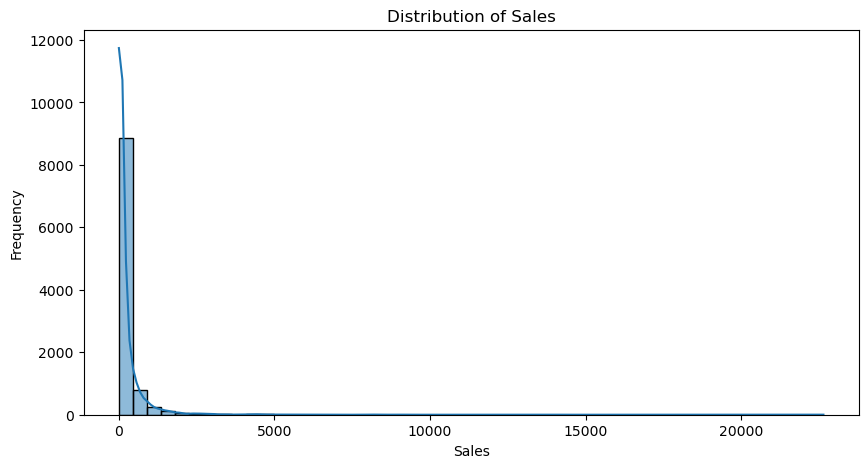

In [82]:
plt.figure(figsize=(10, 5))

sns.histplot(cleaned_df['Sales'], bins=50, kde=True)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

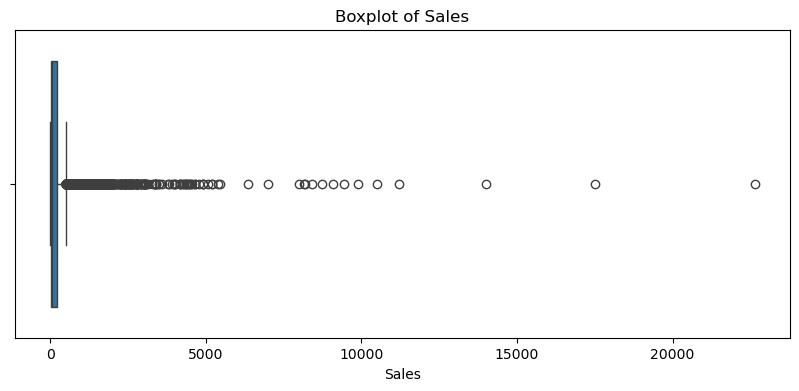

In [83]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=cleaned_df['Sales'])

plt.title('Boxplot of Sales')
plt.xlabel('Sales')

plt.show()

In [84]:
category_sales = (
    cleaned_df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

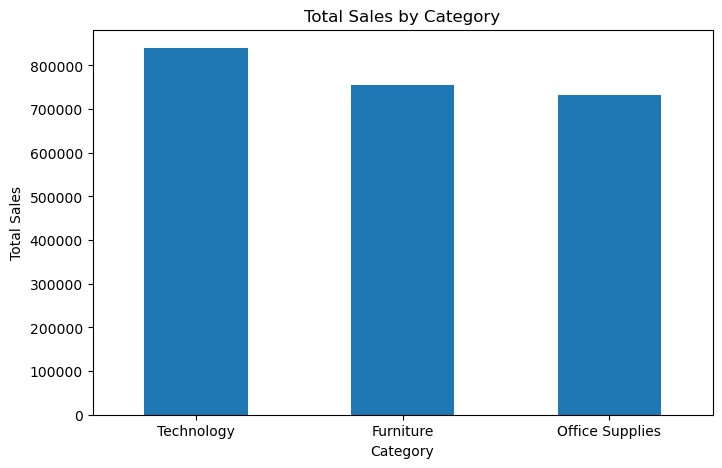

In [85]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.show()

In [86]:
category_profit = (
    cleaned_df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

category_profit

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

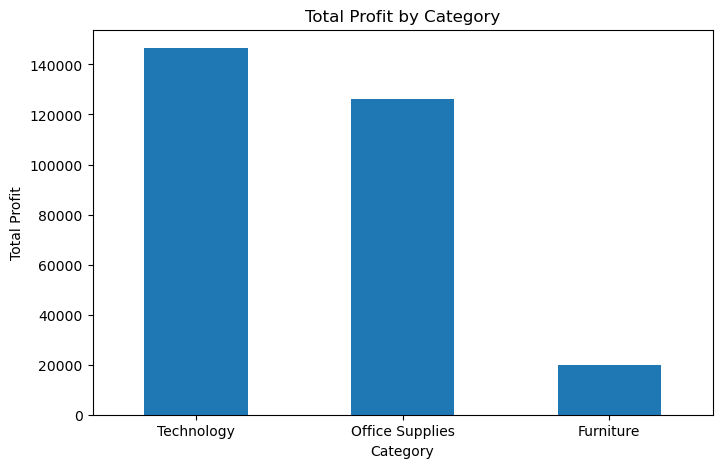

In [87]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=0)

plt.show()

In [88]:
correlation = cleaned_df[
    ['Sales', 'Quantity', 'Discount', 'Profit']
].corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.198457,-0.027756,0.481460
Quantity,0.198457,1.000000,0.007475,0.066145
Discount,-0.027756,0.007475,1.000000,-0.218882
Profit,0.481460,0.066145,-0.218882,1.000000


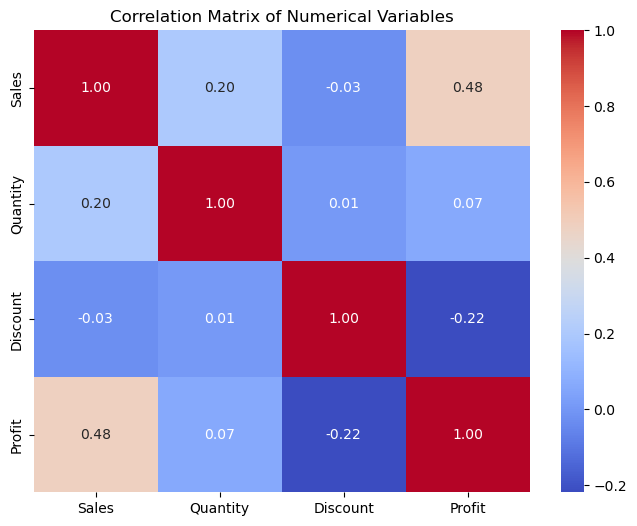

In [89]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [90]:
monthly_sales = (
    cleaned_df
    .set_index('Order Date')
    .resample('ME')['Sales']
    .sum()
)

monthly_sales.head()

Order Date
2023-01-31    14518.055
2023-02-28     4519.892
2023-03-31    56933.909
2023-04-30    28295.345
2023-05-31    26319.767
Freq: ME, Name: Sales, dtype: float64

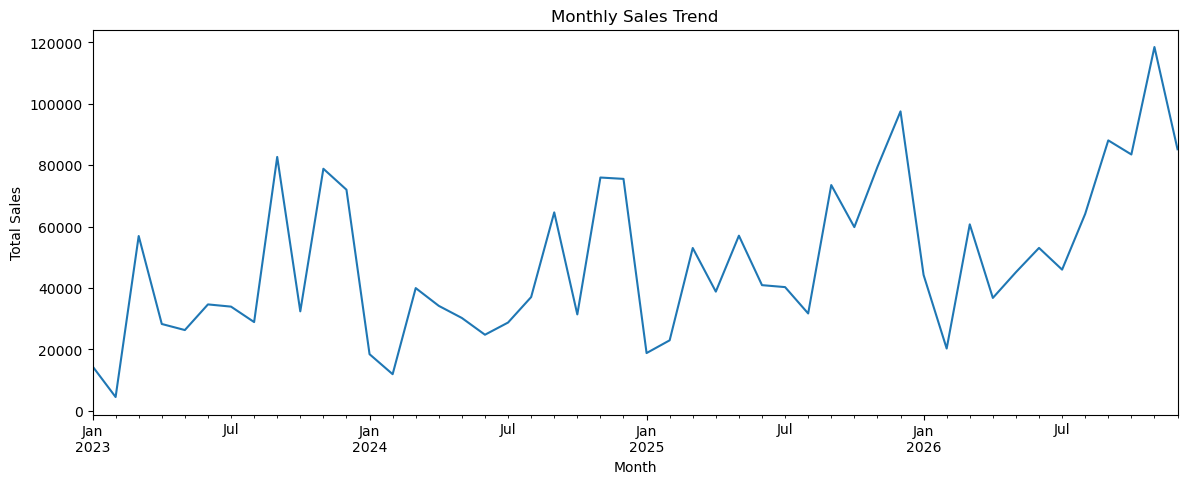

In [91]:
plt.figure(figsize=(14, 5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

In [92]:
highest_sales_month = monthly_sales.idxmax()
highest_sales_value = monthly_sales.max()

lowest_sales_month = monthly_sales.idxmin()
lowest_sales_value = monthly_sales.min()

print("Highest sales month:", highest_sales_month)
print("Highest monthly sales:", highest_sales_value)

print("\nLowest sales month:", lowest_sales_month)
print("Lowest monthly sales:", lowest_sales_value)

Highest sales month: 2026-11-30 00:00:00
Highest monthly sales: 118454.505

Lowest sales month: 2023-02-28 00:00:00
Lowest monthly sales: 4519.892


In [93]:
subcategory_profit = (
    cleaned_df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

subcategory_profit

Sub-Category
Copiers        56093.9365
Phones         45050.8265
Accessories    41936.6357
Paper          34511.5070
Binders        31426.1003
Chairs         27223.5323
Storage        21285.1115
Appliances     18329.4844
Furnishings    13891.7430
Envelopes       6988.0247
Art             6653.1962
Labels          5572.7780
Machines        3461.9769
Fasteners       2428.6358
Supplies       -1171.3945
Bookcases      -3632.0736
Tables        -17753.2061
Name: Profit, dtype: float64

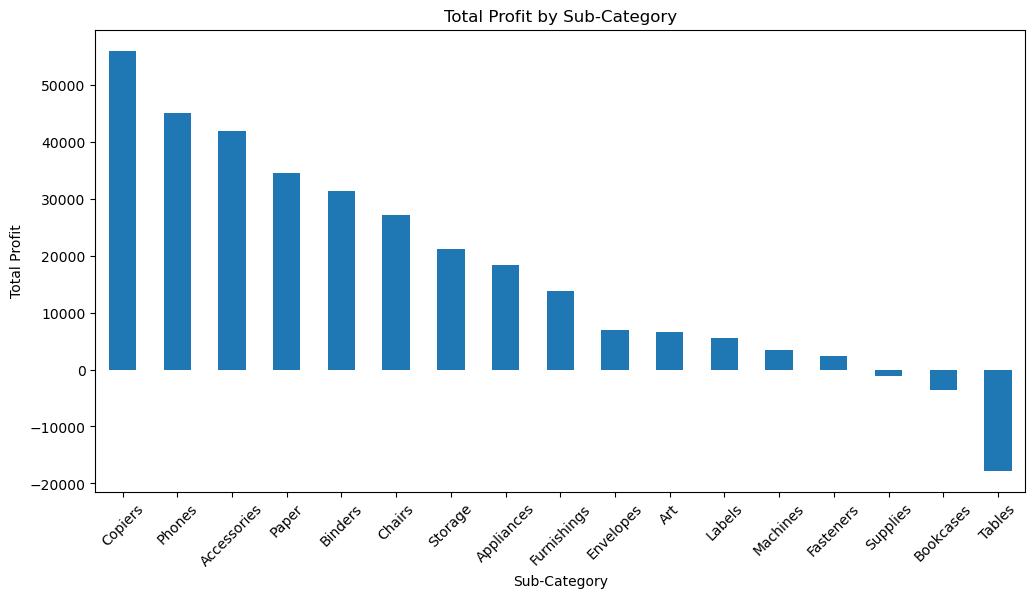

In [94]:
plt.figure(figsize=(12, 6))

subcategory_profit.plot(kind='bar')

plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit')

plt.xticks(rotation=45)

plt.show()

## Key Insights
These are based directly on your actual analysis:

1.Technology generated the highest total sales, with approximately $839,893, followed by Furniture and Office Supplies.

2.Technology also generated the highest total profit, at approximately $146,543, while Furniture generated only about $19,730 despite having substantial sales.

3.Sales and Profit have a moderate positive correlation of 0.48, while Discount and Profit have a negative correlation of -0.22, indicating that higher discounts are associated with lower profitability.

4.Monthly sales fluctuate considerably over time. The highest monthly sales occurred in November 2026 ($118,454.51), while the lowest occurred in February 2023 ($4,519.89).

5.Profitability varies significantly across sub-categories. Copiers had the highest profit ($56,093.94), whereas Tables had a substantial negative profit (-$17,753.21).

## Conclusion

The exploratory data analysis of the Superstore dataset provided useful insights into sales, profitability, product categories, and sales trends over time.

The analysis showed that Technology was the strongest-performing category in terms of both sales and profit. Sales were highly right-skewed, with most transactions having relatively low sales values and a smaller number of high-value transactions.

The correlation analysis showed a moderate positive relationship between Sales and Profit, while Discount had a negative relationship with Profit. The monthly sales analysis also showed significant fluctuations over time.

At the sub-category level, Copiers generated the highest total profit, while Tables recorded the largest negative profit. These findings highlight areas where business performance could potentially be improved through better pricing, discount, and product-level strategies.